ic| 3400982603.py:17 in <module>
    s: Slide(path='E:/datasets/ckb/slides/073-84 [2013] Prost-001.svs',
             shape=(82123, 193224, 3),
             downsamples=(1, 4, 16, 64),
             mpp=0.25,
             driver='Tiff')
    tmb: np.array((1283, 3019, 3), uint8(238 ± 13.3), X∈[23 ... 250], grad=[-0.5711 -1.097 -0.3381])
ic| 3400982603.py:17 in <module>
    s: Slide(path='E:/datasets/ckb/slides/073-84 [2013] Prost-001.svs',
             shape=(82123, 193224, 3),
             downsamples=(1, 4, 16, 64),
             mpp=0.25,
             driver='Tiff')
    tmb: np.array((1283, 3019, 3), uint8(238 ± 13.3), X∈[23 ... 250], grad=[-0.5711 -1.097 -0.3381])


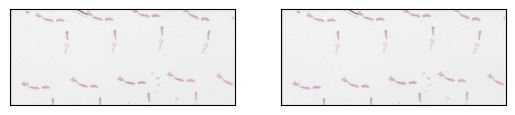

In [1]:
import bipl
import matplotlib.pyplot as plt
from glow import ic
from pathlib import Path

# p = Path('E:/datasets/ckb/slides/27549-68 [2015] PROST-003.svs')
p = next(Path('E:/datasets/ckb/slides').glob('*.svs'))
# p = next(Path('E:/datasets/ckb/_onecell').glob('*.tiff'))
# p = next(Path('E:/datasets/ckb/_pirogov').glob('*.svs'))
# p = next(Path('E:/datasets/ckb/_unim').glob('*.tif'))
s0 = bipl.Slide.open(p)
s1 = bipl.Slide.open(p, icc=True)

fig, axes = plt.subplots(1, 2)
for s, ax in zip((s0, s1), axes):
    tmb = s.levels[-1].numpy()
    ic(s, tmb)
    ax.imshow(tmb)
    ax.set(xticks=[], yticks=[])
plt.show()

In [1]:
import os
from pathlib import Path

os.environ['BIPL_DRIVERS'] = '["openslide"]'

import cv2
import bipl
import tifffile
from bipl.ops import get_fusion
from tqdm import tqdm

In [2]:
ZOOM = 2

p = Path('E:/datasets/ckb/slides/27549-68 [2015] PROST-003.svs')
# p = next(Path('E:/datasets/ckb/slides').glob('*.svs'))
s = bipl.Slide.open(p)

mpp = s.mpp_or_error()
mpp2 = mpp * ZOOM
res2 = 1e4 / mpp2
res2 = round(res2 * 256) / 256
p2 = Path() / Path(s.path).with_suffix('.2.tif').name

E:/datasets/ckb/slides/27549-68 [2015] PROST-003.svs [2](230, 841, 3) -> 60 / 60 -> 567KiB / 567KiB
0.25 4
read @ optimized (512x512) done in 3.03ms
clahe done in 5.09ms
E:/datasets/ckb/slides/27549-68 [2015] PROST-003.svs [2](230, 841, 3) -> 60 / 60 -> 567KiB / 567KiB
E:/datasets/ckb/slides/27549-68 [2015] PROST-003.svs [2](230, 841, 3) -> 60 / 60 -> 567KiB / 567KiB


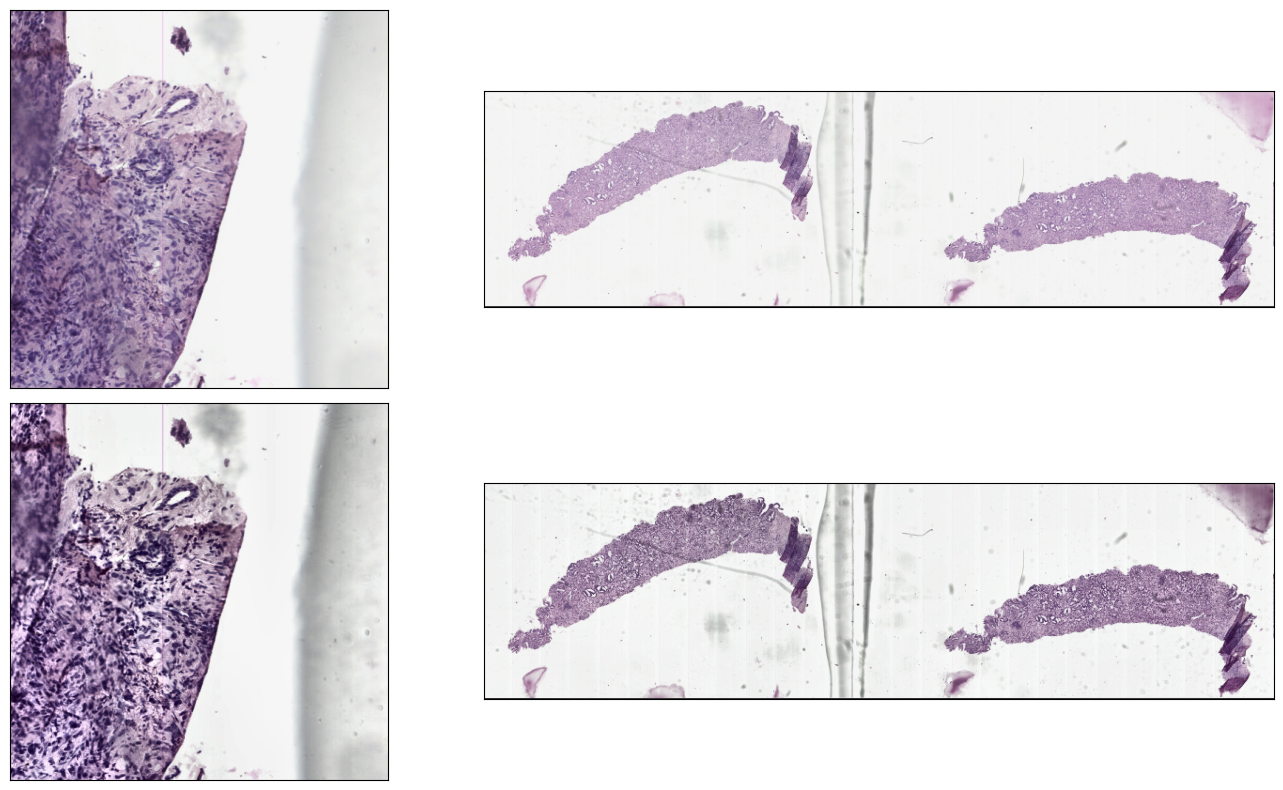

In [9]:
import matplotlib.pyplot as plt
from bipl.io._util import clahe
from glow import timer

tsize = 512
g = 5
fast_mpp = 16.0
fast_z = fast_mpp / s.mpp_or_error()
ims = cv2.cvtColor(s.pool(fast_z).numpy(), cv2.COLOR_RGB2GRAY)
_, ims = cv2.threshold(ims, 150, 255, cv2.THRESH_BINARY_INV)
ims = cv2.GaussianBlur(ims, (g, g), 0)
ims[:g, :] = ims[-g:, :] = 0
ims[:, :g] = ims[:, -g:] = 0
y, x = (*(round(a * fast_z) for a in divmod(ims.argmax(), ims.shape[1])),)

target_mpp = 1.0112
print(mpp, s.best_level_for(target_mpp / mpp)[0])

with timer(f'read @ optimized ({tsize}x{tsize})'):
    im = s.at((y, x), tsize, mpp=target_mpp)
with timer('clahe'):
    im_c = clahe(im)

_, ((a00, a01), (a10, a11)) = plt.subplots(2, 2, figsize=(15, 8))
a00.imshow(im, interpolation='antialiased')
a10.imshow(im_c, interpolation='antialiased')
a01.imshow(s.resample(16.0).numpy(), interpolation='antialiased')
a11.imshow(clahe(s.resample(16.0).numpy()), interpolation='antialiased')

a00.set(xticks=[], yticks=[])
a01.set(xticks=[], yticks=[])
a10.set(xticks=[], yticks=[])
a11.set(xticks=[], yticks=[])
plt.tight_layout()
plt.show()

In [3]:
sp = s.pool(ZOOM)
im0 = get_fusion(
    tqdm(bipl.Mosaic(960, 0).iterate(sp, max_workers=8), desc='read'),
    sp.shape[:2],
)
assert im0 is not None
im0.shape

read: 100%|██████████| 232/232 [00:04<00:00, 53.11it/s]


(7338, 26892, 3)

In [11]:
TILE = 256
LEVELS = 7  # 2,4,8,16,32,64,128

# Generate levels
levels = []
im = im0
with tqdm(range(LEVELS), desc='generate levels') as pb:
    for level in pb:
        im = cv2.resize(im, None, fx=0.5, fy=0.5)
        levels.append(im)
        tqdm.write(str(im.shape))
        if min(im.shape[:2]) < TILE:
            break

# TODO: ICC
with tifffile.TiffWriter(p2, bigtiff=False) as tif:
    metadata = {
        # 'PhysicalSizeX': mpp2,
        # 'PhysicalSizeXUnit': 'µm',
        # 'PhysicalSizeY': mpp2,
        # 'PhysicalSizeYUnit': 'µm',
        'xres': res2,  # ! not helps, description?
        'yres': res2,
    }
    options = {
        'photometric': 'rgb',
        'tile': (TILE, TILE),
        'compression': 'jpeg',
        'compressionargs': {'level': 85},
        'resolutionunit': 'CENTIMETER',
        # 'contiguous': True,
    }
    tif.write(
        im0,
        description='',
        resolution=(res2, res2),
        metadata=metadata,
        # subifds=len(levels[:-1]),  # * if used, qupath pyramid fails, otherwise any qupath is OK
        **options,
    )
    for level, im in enumerate(tqdm(levels[:-1], desc='write sub-IFDs')):
        mag = 2 << level
        tif.write(
            im, resolution=(res2 / mag, res2 / mag), subfiletype=1, **options
        )

    tif.write(levels[-1], metadata={'Name': 'thumbnail'}, subfiletype=9)

(3669, 13446, 3)


(1834, 6723, 3)


(917, 3362, 3)


(458, 1681, 3)


(229, 840, 3)


write sub-IFDs: 100%|██████████| 4/4 [00:00<00:00, 44.85it/s]


In [40]:
for p_ in (
    p,
    p2,
    p2.with_suffix('.ifd.tif'),
    p.parent / 'alt' / p.with_suffix('.tif').name,
):
    # print(p_)
    s_ = bipl.Slide.open(p_)
    print(s_)
    # print(*s_.levels, sep='\n')
    with tifffile.TiffFile(p_) as tif:
        for se in tif.series:
            print(se)
            for lv in se.levels:
                if lv is not se:
                    print(' ', lv)
                for page in lv.pages:
                    print(
                        '   ' + ' >' * bool(page.is_subifd),
                        page.description or (),
                    )
                    # print('\n'.join(f'  {tag.name}={tag.value!r}' for tag in page.tags))
    print()

Slide('E:/datasets/ckb/slides/27549-68 [2015] PROST-003.svs', shape=(14676, 53784, 3), pools=(1, 4, 16), spacing=0.2528, driver=Tiff)
TiffPageSeries 0  'Baseline'  14676x53784x3  uint8  YXS  svs  3 Levels  1 Pages
    Aperio Image Library v12.0.15 
54864x14776 [0,100 53784x14676] (240x240) JPEG/RGB Q=70|AppMag = 40|StripeWidth = 2032|ScanScope ID = SS7315|Filename = 27549-68 [2015] PROST-003|Date = 12/02/18|Time = 18:16:50|Time Zone = GMT+03:00|User = 5d104a14-b348-46be-967c-c8e8c2594a3b|MPP = 0.2528|Left = 20.962778|Top = 16.974380|LineCameraSkew = -0.002095|LineAreaXOffset = 0.016146|LineAreaYOffset = 0.001517|Focus Offset = -0.000500|ImageID = 1014093|Exposure Time = 45|Exposure Scale = 0.000001|DisplayColor = 0|SessonMode = NR|OriginalWidth = 54864|OriginalHeight = 14776|ICC Profile = AT2
  TiffPageSeries 0  'Resolution'  3669x13446x3  uint8  YXS  svs  1 Pages
    Aperio Image Library v12.0.15 
54864x14776 [0,100 53784x14676] (240x240) -> 13446x3669 JPEG/RGB Q=85
  TiffPageSeries 0

Slide(path='E:/datasets/ckb/slides/27549-68 [2015] PROST-003.svs', shape=(14676, 53784, 3), downsamples=(1, 4, 16), mpp=0.25, driver='Tiff')
Slide(path='C:/Users/pmaevskikh/Sources/bipl/27549-68 [2015] PROST-003.2.tif', shape=(7338, 26892, 3), downsamples=(1, 2, 4, 8, 16), mpp=0.5, driver='Tiff')


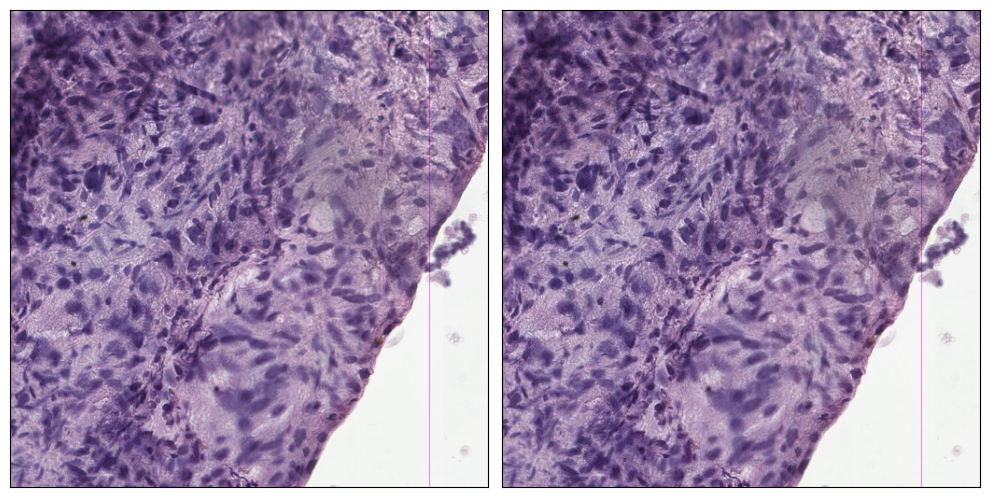

In [12]:
import cv2
import matplotlib.pyplot as plt

tsize = 512
g = 5
fast_z = 64 / s.mpp_or_error()
ims = cv2.cvtColor(s.pool(fast_z).numpy(), cv2.COLOR_RGB2GRAY)
_, ims = cv2.threshold(ims, 150, 255, cv2.THRESH_BINARY_INV)
ims = cv2.GaussianBlur(ims, (g, g), 0)
ims[:g, :] = ims[-g:, :] = 0
ims[:, :g] = ims[:, -g:] = 0
y, x = (*(round(a * fast_z) for a in divmod(ims.argmax(), ims.shape[1])),)

s2 = bipl.Slide.open(p2)
print(s)
print(s2)

_, (a00, a01) = plt.subplots(1, 2, figsize=(10, 10))
a00.imshow(s.at((y, x), tsize, scale=1 / ZOOM))
a01.imshow(s2.at((y // ZOOM, x // ZOOM), tsize, scale=1))
a00.set(xticks=[], yticks=[])
a01.set(xticks=[], yticks=[])
plt.tight_layout()
plt.show()